# Modelado Evaluación

## 1. Definición del problema de Machine Learning

El objetivo inicial de modelado es construir un **clasificador binario** capaz de diferenciar muestras de controles (`n`) frente a muestras asociadas a diabetes tipo 2 (`t2d`) utilizando **únicamente variables taxonómicas** del microbioma intestinal.
<br>
<br>
Este primer modelo se plantea como **baseline supervisado**. No se incluyen variables de metadata como `dataset_name`, `country`, `age`, `gender` o `bmi`, ya que podrían introducir sesgos o confounding. El objetivo es evaluar si las **abundancias microbianas** contienen señal predictiva por sí mismas.

**Variable objetivo:**
- `0`: control (`n`)
- `1`: diabetes tipo 2 (`t2d`)

**Features**
- columnas taxonómicas que empiezan por `k__` 

## 2. Preparación del dataset binario `n` vs `t2d`

### 2.0. Cargar librerías

In [135]:
import numpy as np
import pandas as pd

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y modelos supervisados
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve, 
    auc
)

# Modelo no supervisado
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

### 2.1. Cargar dataset limpio

In [136]:
df_model = pd.read_csv(
    "D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/data/processed/abundance_stoolsubset_clean.csv",
    low_memory=False
)

df_model.shape

(1577, 2135)

### 2.2. Crear subset `n` y `t2d`

In [137]:
df_binary = df_model[df_model["disease"].isin(["n", "t2d"])].copy()

### 2.3. Definir `target`

In [138]:
df_binary["target"] = df_binary["disease"].map({
    "n": 0,
    "t2d": 1
})

df_binary["target"].value_counts()

target
0    710
1    223
Name: count, dtype: int64

### 2.4. Definir `x` y `y`

In [139]:
taxa_cols = [col for col in df_binary.columns if col.startswith("k__")]

X = df_binary[taxa_cols]
y = df_binary["target"]

X.shape, y.shape

((933, 2128), (933,))

## 3. `Train`/`Test`

### 3.1. Separación de datos

In [140]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% para test
    random_state=42,    # Reproducubilidad
    stratify=y          # mantener la proporción de las clases n y t2d en train y test
)

### 3.2. Comprobación de proporciones

In [141]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(target
 0    0.761394
 1    0.238606
 Name: proportion, dtype: float64,
 target
 0    0.759358
 1    0.240642
 Name: proportion, dtype: float64)

## 4. Baseline: `Logistic Regression`

### 4.1. Definición del pipeline

In [142]:
logistic_pipeline = Pipeline(steps=[
    ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),   # aplicar log1p a las abundancias para reducir asimetrías
    ("feature_selection", SelectKBest(score_func=f_classif, k=300)),    # selecciona las 300 variables más relacionadas con el target dentro del train
    ("scaler", StandardScaler()),       # estandariza variables
    ("model", LogisticRegression(       
        max_iter=5000,
        class_weight="balanced",        # compesa el desbalance entre n y t2d
        random_state=42
    ))
])

### 4.2. Entrenamiento del modelo

In [143]:
logistic_pipeline.fit(X_train, y_train)
# Ajusta todo el pipeline usando solo los datos de entrenamiento
# Aprende: la transformación, las features seleccionadas, el escalado, y los coeficientes del modelo

c:\Users\gonza\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 648  649  650  651  669  670  730  731  732  743  744  747  748  750
  751  752  818  819  820  821  822  823  824  833  834  835  875  876
  879  880  945  946  955  956  963  964  965  978 1012 1027 1029 1032
 1038 1039 1040 1063 1064 1085 1086 1094 1095 1103 1104 1119 1128 1129
 1130 1131 1132 1133 1153 1154 1182 1183 1186 1187 1207 1208 1212 1213
 1224 1225 1236 1237 1238 1239 1240 1241 1242 1243 1268 1269 1270 1271
 1272 1273 1286 1287 1288 1289 1290 1291 1304 1305 1329 1338 1339 1340
 1341 1342 1343 1344 1353 1354 1374 1375 1376 1377 1382 1383 1386 1387
 1388 1390 1391 1397 1398 1399 1402 1403 1404 1407 1428 1434 1437 1438
 1439 1440 1441 1442 1443 1446 1447 1448 1475 1476 1477 1478 1499 1500
 1501 1502 1503 1504 1508 1509 1514 1515 1527 1528 1529 1530 1531 1538
 1539 1541 1607 1608 1609 1614 1615 1616 1617 1618 1619 1626 1627 16

,steps,"[('log_transform', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<ufunc 'log1p'>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,'one-to-one'
,kw_args,None


### 4.3. Predicción sobre `test`

In [144]:
# predecir clase final `0` o `1`
y_pred = logistic_pipeline.predict(X_test)

# devuelve la probabilidad estimada de pertenecer a la clase `1`, es decir `t2d`
y_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

### 4.4. Métricas principales

In [145]:
metrics_logistic = {
    "accuracy": accuracy_score(y_test, y_pred),     # aciertos globales
    "precision": precision_score(y_test, y_pred),   # de los predichos como `t2d`
    "recall": recall_score(y_test, y_pred),         # de los `t2d` reales, cuántos detectó
    "f1_score": f1_score(y_test, y_pred),           # equilibrio entre precision y recall
    "roc_auc": roc_auc_score(y_test, y_proba)       # capacidad de separar clases usando probabilidades
}

metrics_logistic

{'accuracy': 0.7593582887700535,
 'precision': 0.5,
 'recall': 0.6222222222222222,
 'f1_score': 0.5544554455445545,
 'roc_auc': 0.7450704225352112}

### 4.5. Reporte de la clasificación

In [146]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["n", "t2d"]
))

              precision    recall  f1-score   support

           n       0.87      0.80      0.84       142
         t2d       0.50      0.62      0.55        45

    accuracy                           0.76       187
   macro avg       0.69      0.71      0.69       187
weighted avg       0.78      0.76      0.77       187



### 4.6. Matriz de confusión

In [147]:
confusion_matrix(y_test, y_pred)

array([[114,  28],
       [ 17,  28]])

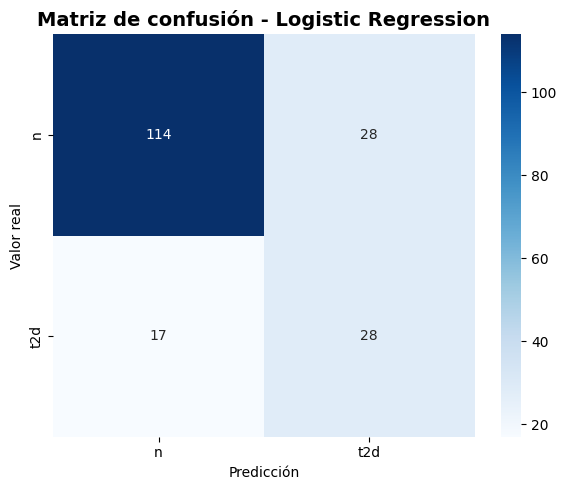

In [148]:
# Gráfico
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["n", "t2d"],
    yticklabels=["n", "t2d"]
)

plt.title("Matriz de confusión - Logistic Regression", fontsize=14, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.tight_layout()

# Guardar gráfico
'''plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/matriz_confusion_LogReg_01.png",
    dpi=300,
    bbox_inches="tight"
)
'''
plt.show()

El modelo baseline de **Logistic Regression** alcanza un *accuracy* de **0.76** y un *ROC-AUC* de **0.75**. Para la clase `t2d`, obtiene un *recall* de **0.62**, lo que indica que detecta aproximadamente el 62% de los casos de diabetes tipo 2. 
<br>
Sin embargo, la *precision* para `t2d` es **0.50**, por lo que el modelo genera un <u>número relevante de **falsos positivos**</u>. Estos resultados sugieren que existe cierta señal predictiva en el perfil taxonómico, aunque será necesario <u>comparar con modelos no lineales</u> y ajustar el preprocesamiento para mejorar el rendimiento.

### 4.7. Conclusión del baseline

La regresión logística funciona como primer baseline interpretable. Los resultados muestran una **capacidad moderada** para diferenciar controles de muestras asociadas a diabetes tipo 2, con *ROC-AUC* de **0.75**. El modelo detecta parte de los casos `t2d`, aunque todavía presenta falsos positivos y falsos negativos. Esto justifica continuar con **modelos no lineales** como **Random Forest**, **Gradient Boosting** y **SVM**, así como probar estrategias de selección de variables y reducción dimensional.

## 5. Entrenamiento de modelos supervisados

### 5.1. Definir pipelines

In [149]:
k_features = 300

models = {
    "Logistic Regression": Pipeline(steps=[
        ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("feature_selection", SelectKBest(score_func=f_classif, k=k_features)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("feature_selection", SelectKBest(score_func=f_classif, k=k_features)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("feature_selection", SelectKBest(score_func=f_classif, k=k_features)),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]),

    "SVM": Pipeline(steps=[
        ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("feature_selection", SelectKBest(score_func=f_classif, k=k_features)),
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]),

    "KNN": Pipeline(steps=[
        ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("feature_selection", SelectKBest(score_func=f_classif, k=k_features)),
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ])
}

## 6. Evaluación comparativa

### 6.1. Función para entrenar y evaluar

In [150]:
def evaluate_model(model_name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }

    return metrics, y_pred, y_proba, pipeline

### 6.2. Entrenar todos los modelos

In [151]:
results = []
trained_models = {}
predictions = {}

for model_name, pipeline in models.items():
    metrics, y_pred_model, y_proba_model, trained_pipeline = evaluate_model(
        model_name,
        pipeline,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results.append(metrics)
    trained_models[model_name] = trained_pipeline
    predictions[model_name] = {
        "y_pred": y_pred_model,
        "y_proba": y_proba_model
    }

c:\Users\gonza\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 648  649  650  651  669  670  730  731  732  743  744  747  748  750
  751  752  818  819  820  821  822  823  824  833  834  835  875  876
  879  880  945  946  955  956  963  964  965  978 1012 1027 1029 1032
 1038 1039 1040 1063 1064 1085 1086 1094 1095 1103 1104 1119 1128 1129
 1130 1131 1132 1133 1153 1154 1182 1183 1186 1187 1207 1208 1212 1213
 1224 1225 1236 1237 1238 1239 1240 1241 1242 1243 1268 1269 1270 1271
 1272 1273 1286 1287 1288 1289 1290 1291 1304 1305 1329 1338 1339 1340
 1341 1342 1343 1344 1353 1354 1374 1375 1376 1377 1382 1383 1386 1387
 1388 1390 1391 1397 1398 1399 1402 1403 1404 1407 1428 1434 1437 1438
 1439 1440 1441 1442 1443 1446 1447 1448 1475 1476 1477 1478 1499 1500
 1501 1502 1503 1504 1508 1509 1514 1515 1527 1528 1529 1530 1531 1538
 1539 1541 1607 1608 1609 1614 1615 1616 1617 1618 1619 1626 1627 16

### 6.3. Tabla comparativa

In [152]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="roc_auc",
    ascending=False
)

results_df

,model,accuracy,precision,recall,f1_score,roc_auc
2,Gradient Boosting,0.764706,0.513514,0.422222,0.463415,0.792488
1,Random Forest,0.759358,0.500000,0.111111,0.181818,0.783255
3,SVM,0.716578,0.435484,0.600000,0.504673,0.766197
0,Logistic Regression,0.759358,0.500000,0.622222,0.554455,0.745070
4,KNN,0.748663,0.428571,0.133333,0.203390,0.631534


### 6.4. Gráfico comparativo

In [153]:
# Paleta general del proyecto
project_palette = {
    "primary": "#2F5D62",
    "secondary": "#5E8B7E",
    "accent": "#D88C3A",
    "danger": "#B85750",
    "neutral": "#6B7280",
    "light": "#F3F4F6",
    "dark": "#1F2937"
}

In [154]:
# Paleta específica para disease
disease_palette = {
    "n": "#2F5D62",
    "t2d": "#D88C3A",
    "ibd_ulcerative_colitis": "#7A5195",
    "cirrhosis": "#B85750",
    "obesity": "#5E8B7E",
    "impaired_glucose_tolerance": "#E0A458",
    "cancer": "#4C78A8",
    "n_relative": "#8C8C8C",
    "stec2-positive": "#C44E52",
    "leanness": "#76B7B2",
    "small_adenoma": "#9C755F",
    "ibd_crohn_disease": "#59A14F",
    "large_adenoma": "#AF7AA1",
    "overweight": "#F28E2B"
}

In [155]:
# Paleta específica para modelos
model_palette = {
    "Logistic Regression": project_palette["primary"],
    "Random Forest": project_palette["secondary"],
    "Gradient Boosting": project_palette["accent"],
    "SVM": "#7A5195",
    "KNN": project_palette["danger"]
}

C:\Users\gonza\AppData\Local\Temp\ipykernel_18844\1385601742.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


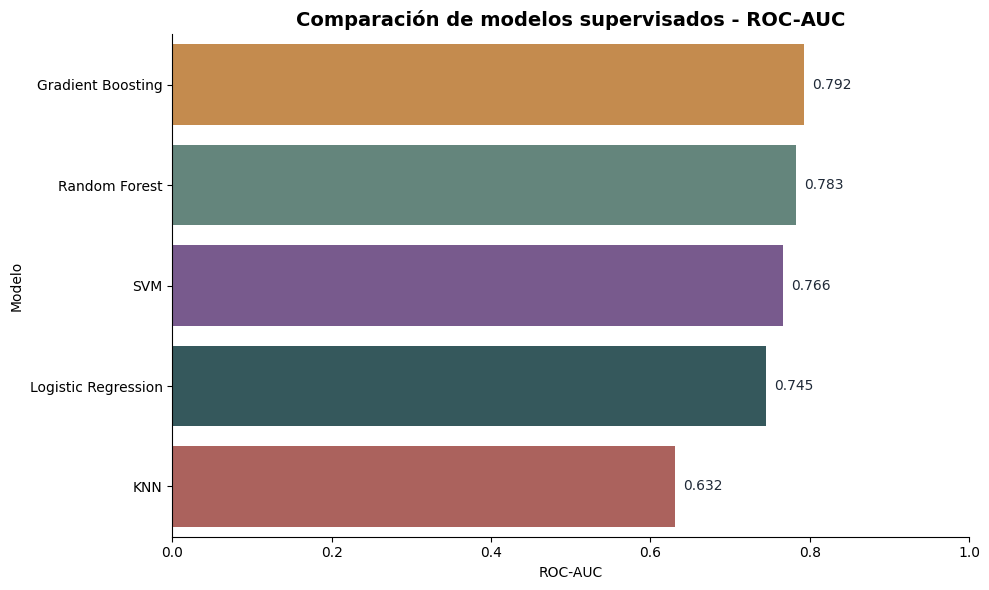

In [156]:
# Gráficos
plt.figure(figsize=(10, 6))

bar_colors = [
    model_palette.get(model, project_palette["neutral"])
    for model in results_df["model"]
]

ax = sns.barplot(
    data=results_df,
    x="roc_auc",
    y="model",
    palette=bar_colors
)

for i, row in results_df.reset_index(drop=True).iterrows():
    ax.text(
        row["roc_auc"] + 0.01,
        i,
        f"{row['roc_auc']:.3f}",
        va="center",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Comparación de modelos supervisados - ROC-AUC", fontsize=14, fontweight="bold")
plt.xlabel("ROC-AUC")
plt.ylabel("Modelo")
plt.xlim(0, 1)

sns.despine()
plt.tight_layout()

# Guardar gráfico
'''
plt.savefig(
     f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/comparacion_modelos_roc_auc.png",
     dpi=300,
     bbox_inches="tight"
)'''

plt.show()

## 7. Interpretación

- `Gradient Boosting` separa mejor las clases en términos generales (ROC-AUC más alto).
- `Logistic Regression` tiene el mejor f1_score y el mayor recall para t2d.
- `Random Forest` tiene buen ROC-AUC, pero detecta muy pocos casos t2d con el umbral actual.
- `SVM` tiene recall razonable, pero precisión más baja.
- `KNN` es el más débil.

El modelo con mayor capacidad global de separación fue `Gradient Boosting`, pero `Logistic Regression` presentó mejor equilibrio entre *precision* y *recall* para la clase minoritaria `t2d`. La elección del modelo final dependerá de si se prioriza la separación global (*ROC-AUC*) o la detección de casos `t2d` (*recall/f1-score*).

* Mejor ROC-AUC: `Gradient Boosting`
<br>
* Baseline más equilibrado: `Logistic Regression`

La comparación de modelos muestra que Gradient Boosting obtiene el mayor ROC-AUC (0.79), indicando la mejor capacidad global de separación entre controles y diabetes tipo 2. Sin embargo, Logistic Regression alcanza el mejor F1-score y el mayor recall para la clase `t2d`, lo que lo convierte en un baseline fuerte e interpretable. Random Forest presenta un ROC-AUC competitivo, pero con bajo recall para `t2d`, sugiriendo que el umbral de decisión por defecto no favorece la detección de la clase minoritaria. Estos resultados indican que existe señal predictiva en el microbioma, aunque será necesario ajustar hiperparámetros, umbrales y estrategias de balanceo antes de seleccionar un modelo final.

### 7.1. Matrices de confusión comparativas

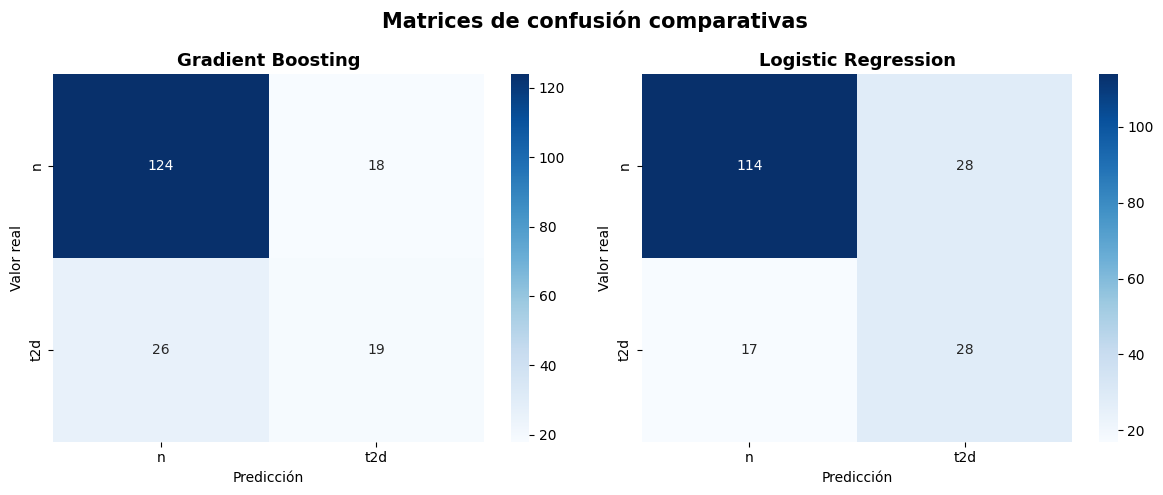

In [157]:
models_to_plot = ["Gradient Boosting", "Logistic Regression"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model_name in zip(axes, models_to_plot):
    y_pred_model = predictions[model_name]["y_pred"]
    cm = confusion_matrix(y_test, y_pred_model)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["n", "t2d"],
        yticklabels=["n", "t2d"],
        ax=ax
    )

    ax.set_title(model_name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")

plt.suptitle("Matrices de confusión comparativas", fontsize=15, fontweight="bold")
plt.tight_layout()

# Guardar gráfico
'''plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/confusion_matrices_gradient_logistic.png",
    dpi=300,
    bbox_inches="tight"
)'''

plt.show()

Lectura:
- Arriba izquierda: `n` predichos correctamente como `n`
- Arriba derecha: `n` clasificados erróneamente como `t2d`
- Abajo izquierda: `t2d` clasificados erróneamente como `n`
- Abajo derecha: `t2d` predichos correctamente como `t2d`

##### **Gradient Boosting**
**Interpretación**:

- Acierta 124 controles `n`.
- Confunde 18 controles como `t2d`.
- Detecta 19 de 45 casos `t2d`.
- Se le escapan 26 casos `t2d`.

Es más conservador prediciendo `t2d`. Por eso tiene mejor `ROC-AUC`, pero menor `recall`.

##### **Logistic Regression**
**Interpretación**:

- Acierta 114 controles `n`.
- Confunde 28 controles como `t2d`.
- Detecta 28 de 45 casos `t2d`.
- Se le escapan 17 casos `t2d`.

Detecta mejor la clase `t2d`, aunque a costa de más falsos positivos.

La matriz de confusión muestra diferencias importantes entre los dos modelos principales. **Gradient Boosting** clasifica mejor la clase mayoritaria `n` y obtiene el mayor `ROC-AUC`, pero detecta menos casos `t2d`. **Logistic Regression** genera más falsos positivos, pero identifica más casos reales de `t2d`, logrando mejor `recall` y `F1-score` para la clase minoritaria. 
<br>
Dado que el objetivo exploratorio es identificar muestras potencialmente asociadas a diabetes tipo 2, **Logistic Regression** puede considerarse un baseline especialmente útil, mientras que **Gradient Boosting** queda como candidato fuerte por su capacidad global de separación.

## 8. Curvas ROC comparativas

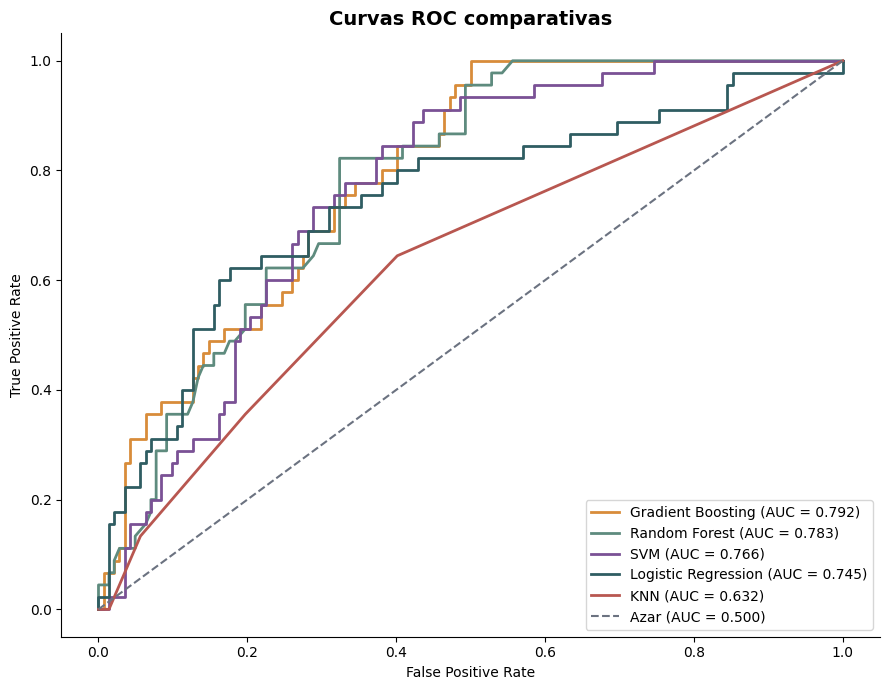

In [158]:
# Gráficos
plt.figure(figsize=(9, 7))

for model_name in results_df["model"]:
    y_proba_model = predictions[model_name]["y_proba"]

    fpr, tpr, _ = roc_curve(y_test, y_proba_model)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {roc_auc:.3f})",
        color=model_palette.get(model_name, project_palette["neutral"]),
        linewidth=2
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color=project_palette["neutral"],
    linewidth=1.5,
    label="Azar (AUC = 0.500)"
)

plt.title("Curvas ROC comparativas", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

sns.despine()
plt.tight_layout()

'''# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/curvas_roc_comparativas.png",
    dpi=300,
    bbox_inches="tight"
)'''

plt.show()

Las curvas ROC comparan la capacidad de los modelos para separar las clases `n` y `t2d` a distintos umbrales de decisión. 
- **Gradient Boosting** obtiene el mayor `AUC`, seguido de **Random Forest** y **SVM**, lo que indica mejor capacidad global de ranking/separación. 
- **Logistic Regression**, aunque no obtiene el mayor `AUC`, presenta mejor equilibrio en `recall` y `F1-score` para la clase `t2d`, por lo que sigue siendo un baseline interpretable relevante.

## 9. Conclusión de modelos supervisados

Se entrenaron cinco modelos supervisados para clasificar muestras `n` vs `t2d` a partir de abundancias taxonómicas del microbioma. Todos los modelos se evaluaron sobre el mismo conjunto de test, manteniendo el preprocesamiento dentro de pipelines para evitar fuga de información.

**Gradient Boosting** obtuvo el mejor `ROC-AUC` (0.79), indicando la mayor capacidad global de separación entre clases. Sin embargo, **Logistic Regression** alcanzó el mejor `F1-score` y el mayor `recall` para la clase `t2d`, detectando 28 de 45 casos reales de diabetes tipo 2. 

Dado el contexto exploratorio del proyecto, **Logistic Regression** se mantiene como baseline interpretable y útil para detectar posibles muestras asociadas a `t2d`, mientras que **Gradient Boosting** se considera un candidato fuerte para optimización posterior.

## 10. Modelo no supervisado: ``PCA`` + ``KMeans``

**Objetivo**: Explorar si las muestras sea grupan naturalmente según su perfil de microbioma y si esos clusters tienen relación con ``n``/``t2d``

### 10.1. Preparar datos para clustering

In [159]:
# Transformación logarítmica y escalado
X_cluster_log = np.log1p(X)     # reduce asimetría de abundancias

scaler_cluster = StandardScaler()   # escala variables para que todas tengan media 0 y desviación estándar 1
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster_log)

### 10.2. Reducir dimensiones con PCA

In [160]:
# Reducir ruido y dimensionalidad (2128 variables taxonómicas a 20 PCs)
pca_cluster = PCA(n_components=20, random_state=42)

X_cluster_pca = pca_cluster.fit_transform(X_cluster_scaled)

In [161]:
# Calcular la varianza explicada
explained_variance_cluster = pca_cluster.explained_variance_ratio_.sum() * 100

explained_variance_cluster

np.float64(34.50989456841714)

### 10.3. Entrenar KMeans

In [162]:
# Problema binario (n y t2d)
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_cluster_pca)

### 10.4. Evaluar ``Silhouette Score``

In [163]:
# Evaluar la calidad del clustering
# Rango aproximado:
#   - cercano a 1: clusters bien separados
#   - cercano a 0: clusters solapados
#   - negativo: mala asignación
silhouette = silhouette_score(X_cluster_pca, clusters)

silhouette

0.9360519370939298

### 10.5. Comparar clusters con clases reales

In [164]:
cluster_comparison = pd.crosstab(
    pd.Series(clusters, name="cluster"),
    y.reset_index(drop=True).map({0: "n", 1: "t2d"})
)

cluster_comparison

target,n,t2d
cluster,,
0,2,0
1,708,223


``KMeans`` **no está separando** ``n`` y ``t2d``.
<br>
Creó un cluster pequeñísimo con 2 muestras (probablemente *outliers*) y metió casi todo el dataset en el otro cluster.
<br>

Posibles razones:
* La señal clínica es sutil.
* Hay mucha variabilidad individual.
* Hay alta dimensionalidad y sparsity.
* ``KMeans`` busca clusters esféricos y simples.
* Puede haber *outliers* dominando la separación.
* ``n`` y ``t2d`` están mezclados globalmente.

### 10.6. Visualizar clusters en PCA 2D

In [165]:
# PCA con 2 componentes solo para visualizar (no es el clustering principal)
pca_cluster_2d = PCA(n_components=2, random_state=42)

X_cluster_pca_2d = pca_cluster_2d.fit_transform(X_cluster_scaled)

In [166]:
# Guardar coordenadas para la visualización
cluster_plot_df = pd.DataFrame({
    "PC1": X_cluster_pca_2d[:, 0],
    "PC2": X_cluster_pca_2d[:, 1],
    "cluster": clusters.astype(str),
    "disease": y.reset_index(drop=True).map({0: "n", 1: "t2d"})
})

El clustering ``KMeans`` con `k=2` no reproduce la separación clínica `n` vs `t2d`. Uno de los clusters contiene únicamente 2 muestras, mientras que el otro agrupa la práctica totalidad del dataset. Esto sugiere que la estructura dominante capturada por ``KMeans`` está más relacionada con *outliers* o variabilidad global que con la condición clínica. Por tanto, la distinción entre controles y diabetes tipo 2 <u>no aparece como una agrupación natural simple</u>, aunque los modelos supervisados <u>sí muestran señal predictiva moderada</u>.

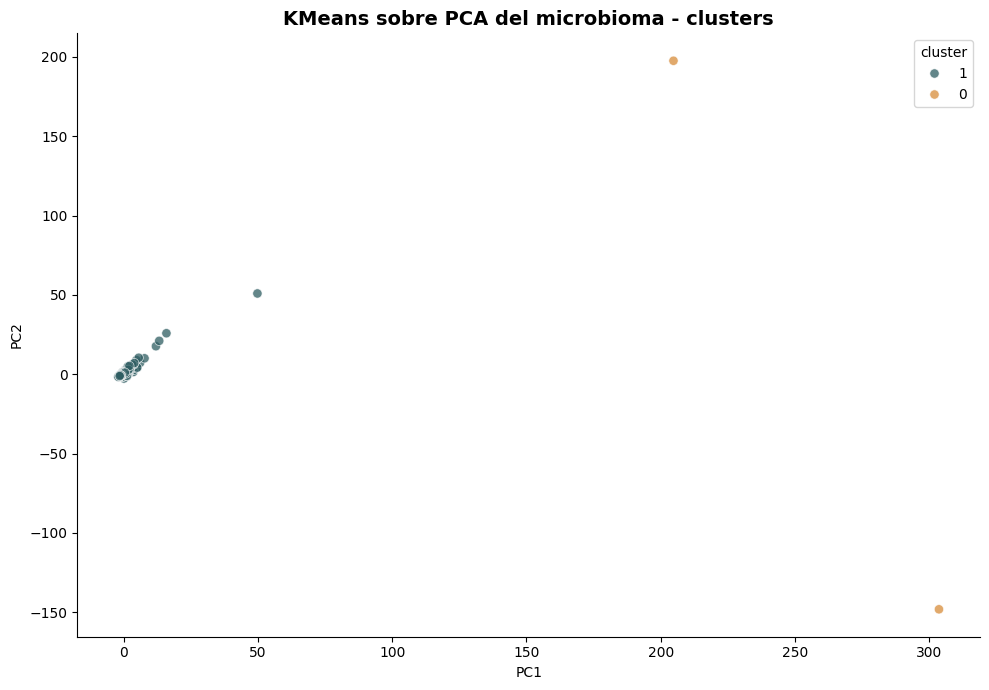

In [167]:
# Gráfico
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=cluster_plot_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette=["#2F5D62", "#D88C3A"],
    alpha=0.75,
    s=45
)

plt.title("KMeans sobre PCA del microbioma - clusters", fontsize=14, fontweight="bold")
plt.xlabel("PC1")
plt.ylabel("PC2")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
     f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/kmeans_pca_clusters.png",
     dpi=300,
     bbox_inches="tight"
)

plt.show()

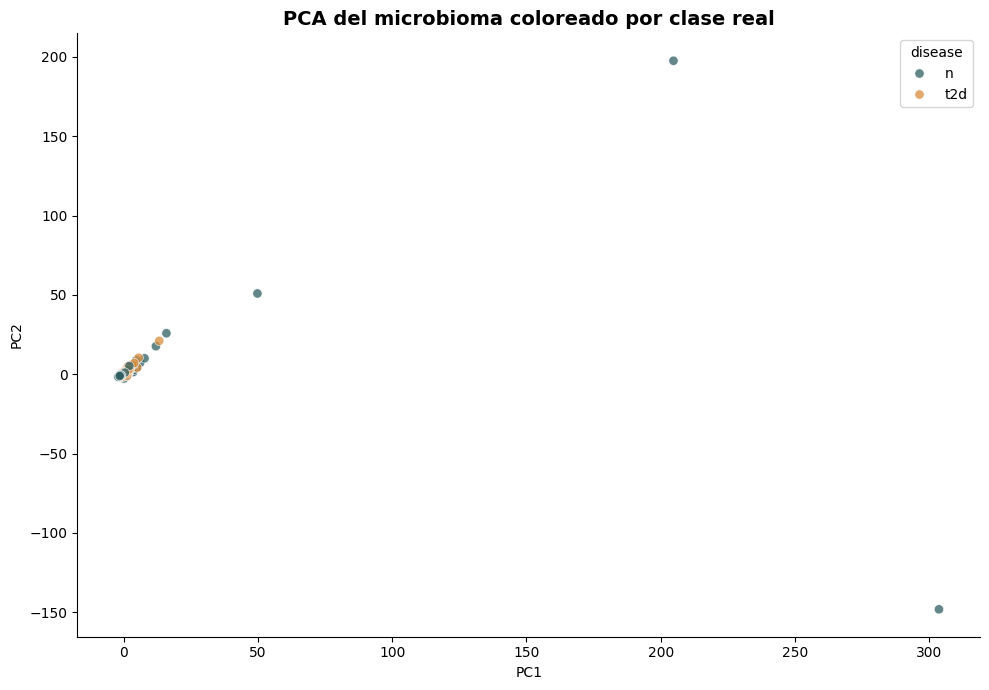

In [168]:
# Gráfico por etiqueta real
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=cluster_plot_df,
    x="PC1",
    y="PC2",
    hue="disease",
    palette={"n": "#2F5D62", "t2d": "#D88C3A"},
    alpha=0.75,
    s=45
)

plt.title("PCA del microbioma coloreado por clase real", fontsize=14, fontweight="bold")
plt.xlabel("PC1")
plt.ylabel("PC2")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
     f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/kmeans_pca_real_labels..png",
     dpi=300,
     bbox_inches="tight"
)

plt.show()

### 10.7. Conclusión de modelos no supervisados

El modelo KMeans con `k=2` obtuvo un ``silhouette score`` elevado (**0.936**). Sin embargo, la comparación con las clases reales muestra que uno de los clusters contiene solo 2 muestras, mientras que el otro agrupa prácticamente todo el dataset. Esto indica que el clustering está capturando *outliers* o variabilidad extrema, no una separación natural entre controles (`n`) y diabetes tipo 2 (`t2d`). Por tanto, aunque la métrica interna parece alta, el resultado <u>no es clínicamente útil para este objetivo</u>.

El análisis no supervisado sugiere que la distinción `n` vs `t2d` no emerge como dos clusters naturales simples en el espacio PCA utilizado. Esto refuerza la necesidad de utilizar modelos supervisados, capaces de aprender señales más sutiles y combinaciones complejas de taxones.

## 11. Optimización de hiperparámetros

Tras la comparación inicial de modelos, se seleccionan dos candidatos para optimización:

- `Gradient Boosting`, por obtener el mayor ROC-AUC.
- `Logistic Regression`, por obtener el mejor recall y F1-score para la clase `t2d`.

La optimización se realiza mediante <u>validación cruzada estratificada</u> sobre el conjunto de **entrenamiento**. El conjunto de ``test`` se mantiene separado hasta la evaluación final de cada modelo optimizado.

### 11.1. Preprocesamiento común para la optimización

Las optimizaciones mantienen la misma lógica de preprocesamiento utilizada en los modelos base:

- Transformación `log1p` para suavizar la distribución de abundancias.
- Selección de variables con `SelectKBest`.
- Escalado con `StandardScaler` solo en modelos sensibles a la escala.
- Uso de `Pipeline` para evitar fuga de información.

##### 11.1.1. Estrategia de validación cruzada

In [169]:
cv_strategy = StratifiedKFold(
    n_splits=3,     # Validación cruzada de 3 folds
    shuffle=True,   # Mantener la proporción de clases en cada fold
    random_state=42
)

##### 11.1.2. Criterios de optimización

Se usan criterios de optimización distintos según el rol de cada modelo:

- `Gradient Boosting`: se optimiza con `ROC-AUC`, ya que fue el mejor modelo en capacidad global de separación.
- `Logistic Regression`: se optimiza con `F1-score`, ya que el objetivo es equilibrar precision y recall para la clase minoritaria `t2d`.

### 11.2. Optimización de ``Gradient Boosting``

Dado que `Gradient Boosting` obtuvo el mayor `ROC-AUC` en la comparación inicial, se selecciona como primer candidato para optimización de hiperparámetros.

##### 11.2.1. Definir pipeline base para la optimización

In [170]:
gb_pipeline = Pipeline(steps=[
    ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("model", GradientBoostingClassifier(random_state=42))
])

##### 11.2.2. Definir grid de parámetros

In [171]:
# Probar combinaciones de:
#   - número de features seleccionados, 
#   - número de árboles, 
#   - learning rate
#   - profundidad máxima de cada árbol
param_grid = {
    "feature_selection__k": [100, 300, 500],
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

In [172]:
cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

##### 11.2.3. Ejecutar ``GridSearchCV``

In [173]:
gb_grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

gb_grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


c:\Users\gonza\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 648  649  650  651  669  670  730  731  732  743  744  747  748  750
  751  752  818  819  820  821  822  823  824  833  834  835  875  876
  879  880  945  946  955  956  963  964  965  978 1012 1027 1029 1032
 1038 1039 1040 1063 1064 1085 1086 1094 1095 1103 1104 1119 1128 1129
 1130 1131 1132 1133 1153 1154 1182 1183 1186 1187 1207 1208 1212 1213
 1224 1225 1236 1237 1238 1239 1240 1241 1242 1243 1268 1269 1270 1271
 1272 1273 1286 1287 1288 1289 1290 1291 1304 1305 1329 1338 1339 1340
 1341 1342 1343 1344 1353 1354 1374 1375 1376 1377 1382 1383 1386 1387
 1388 1390 1391 1397 1398 1399 1402 1403 1404 1407 1428 1434 1437 1438
 1439 1440 1441 1442 1443 1446 1447 1448 1475 1476 1477 1478 1499 1500
 1501 1502 1503 1504 1508 1509 1514 1515 1527 1528 1529 1530 1531 1538
 1539 1541 1607 1608 1609 1614 1615 1616 1617 1618 1619 1626 1627 16

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'feature_selection__k': [100, 300, ...], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [2, 3], 'model__n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,func,<ufunc 'log1p'>


##### 11.2.4. Identificar los mejores hiperparámetros

In [174]:
# Mejor combinación encontrada
gb_grid_search.best_params_

{'feature_selection__k': 300,
 'model__learning_rate': 0.05,
 'model__max_depth': 3,
 'model__n_estimators': 200}

**Interpretación**:
* ``k=300``: confirma que seleccionar 300 taxones es razonable.
* ``learning_rate=0.05``: aprendizaje más gradual que el valor base típico ``0.1``.
* ``n_estimators=200``: más árboles para compensar ese aprendizaje más lento.
* ``max_depth=3``: árboles moderadamente complejos.

La mejor configuración encontrada para Gradient Boosting mantiene `k=300` features seleccionadas, con `learning_rate=0.05`, `max_depth=3` y `n_estimators=200`. El mejor ROC-AUC promedio en validación cruzada sobre el conjunto de entrenamiento fue 0.833. El uso de un learning rate menor junto con más estimadores sugiere un modelo más gradual y potencialmente más robusto frente al sobreajuste.

In [175]:
# Mejor ROC-AUC promedio en validación cruzada sobre train
gb_grid_search.best_score_

np.float64(0.8334476335219719)

##### 11.2.5. Evaluación del modelo ``Gradient Boosting`` optimizado

11.2.5.1. Recuperar el mejor modelo

In [176]:
# Guardar el mejor pipeline encontrado por GridSearchCV
best_gb_model = gb_grid_search.best_estimator_

11.2.5.2. Predecir sobre ``test``

In [177]:
y_pred_gb_optimized = best_gb_model.predict(X_test)
y_proba_gb_optimized = best_gb_model.predict_proba(X_test)[:, 1]

11.2.5.3. Calcular métricas

In [178]:
# Evaluar el modelo optimizado sobre test
metrics_gb_optimized = {
    "model": "Gradient Boosting Optimized",
    "accuracy": accuracy_score(y_test, y_pred_gb_optimized),
    "precision": precision_score(y_test, y_pred_gb_optimized),
    "recall": recall_score(y_test, y_pred_gb_optimized),
    "f1_score": f1_score(y_test, y_pred_gb_optimized),
    "roc_auc": roc_auc_score(y_test, y_proba_gb_optimized)
}

metrics_gb_optimized

{'model': 'Gradient Boosting Optimized',
 'accuracy': 0.7593582887700535,
 'precision': 0.5,
 'recall': 0.35555555555555557,
 'f1_score': 0.4155844155844156,
 'roc_auc': 0.788262910798122}

11.2.5.4. Classification report

In [179]:
print(classification_report(
    y_test,
    y_pred_gb_optimized,
    target_names=["n", "t2d"]
))

              precision    recall  f1-score   support

           n       0.81      0.89      0.85       142
         t2d       0.50      0.36      0.42        45

    accuracy                           0.76       187
   macro avg       0.66      0.62      0.63       187
weighted avg       0.74      0.76      0.74       187



11.2.5.5. Matriz de confusión

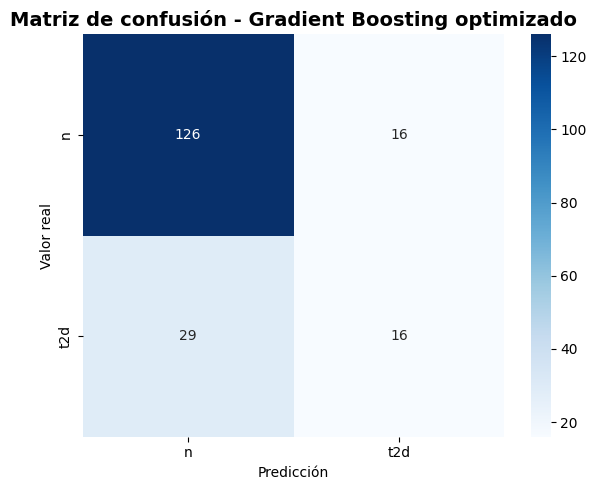

In [180]:
cm_gb_optimized = confusion_matrix(y_test, y_pred_gb_optimized)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_gb_optimized,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["n", "t2d"],
    yticklabels=["n", "t2d"]
)

plt.title("Matriz de confusión - Gradient Boosting optimizado", fontsize=14, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.tight_layout()

# Guardar gráfico
plt.savefig(
     f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/confusion_matrix_gradient_boosting_optimized.png",
     dpi=300,
     bbox_inches="tight"
)

plt.show()

11.2.5.6. Comparar modelo base *vs*. modelo optimizado

In [181]:
gb_base_metrics = results_df[results_df["model"] == "Gradient Boosting"].copy()

gb_comparison = pd.concat([
    gb_base_metrics,
    pd.DataFrame([metrics_gb_optimized])
], ignore_index=True)

gb_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
0,Gradient Boosting,0.764706,0.513514,0.422222,0.463415,0.792488
1,Gradient Boosting Optimized,0.759358,0.500000,0.355556,0.415584,0.788263


La optimización de ``Gradient Boosting`` obtuvo un ``ROC-AUC`` promedio de **0.833** en validación cruzada sobre ``train``. Sin embargo, al evaluar en el conjunto de test, el modelo optimizado <u>**no mejoró al Gradient Boosting base**</u>. El ``ROC-AUC`` bajó ligeramente de **0.792** a **0.788**, y también disminuyeron el ``recall`` y el ``F1-score`` para la clase `t2d`.
<br>
Por tanto, la configuración optimizada <u>no se selecciona como modelo final</u>. Este resultado sugiere que la mejora observada en validación cruzada no se tradujo en mejor generalización sobre el conjunto de test.

### 11.3. Optimización de ``Logistic Regression``

Dado que `Logistic Regression` obtuvo el mejor `recall` y `F1-score` para la clase `t2d`, se optimiza como segundo candidato. Se utiliza `F1-score` como métrica principal para equilibrar precision y recall.

#### 11.3.1. Definir pipeline base para la optimización

In [182]:
logistic_opt_pipeline = Pipeline(steps=[
    ("log_transform", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

#### 11.3.2. Definir grid de parámetros

In [183]:
param_grid_logistic = {
    "feature_selection__k": [100, 300, 500, 800],
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced"]
}

#### 11.3.3. Ejecutar ``GridSearchCV``

In [184]:
logistic_grid_search = GridSearchCV(
    estimator=logistic_opt_pipeline,
    param_grid=param_grid_logistic,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

logistic_grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 64 candidates, totalling 192 fits


c:\Users\gonza\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 648  649  650  651  669  670  730  731  732  743  744  747  748  750
  751  752  818  819  820  821  822  823  824  833  834  835  875  876
  879  880  945  946  955  956  963  964  965  978 1012 1027 1029 1032
 1038 1039 1040 1063 1064 1085 1086 1094 1095 1103 1104 1119 1128 1129
 1130 1131 1132 1133 1153 1154 1182 1183 1186 1187 1207 1208 1212 1213
 1224 1225 1236 1237 1238 1239 1240 1241 1242 1243 1268 1269 1270 1271
 1272 1273 1286 1287 1288 1289 1290 1291 1304 1305 1329 1338 1339 1340
 1341 1342 1343 1344 1353 1354 1374 1375 1376 1377 1382 1383 1386 1387
 1388 1390 1391 1397 1398 1399 1402 1403 1404 1407 1428 1434 1437 1438
 1439 1440 1441 1442 1443 1446 1447 1448 1475 1476 1477 1478 1499 1500
 1501 1502 1503 1504 1508 1509 1514 1515 1527 1528 1529 1530 1531 1538
 1539 1541 1607 1608 1609 1614 1615 1616 1617 1618 1619 1626 1627 16

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'feature_selection__k': [100, 300, ...], 'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l1', 'l2'], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,func,<ufunc 'log1p'>


#### 11.3.4. Identificar los mejores hiperparámetros

In [185]:
logistic_grid_search.best_params_

{'feature_selection__k': 300,
 'model__C': 0.01,
 'model__class_weight': None,
 'model__penalty': 'l2',
 'model__solver': 'liblinear'}

In [186]:
logistic_grid_search.best_score_

np.float64(0.55740958349654)

#### 11.3.5. Evaluación del modelo ``Logistic Regression`` optimizado

11.3.5.1. Recuperar el mejor modelo

In [187]:
best_logistic_model = logistic_grid_search.best_estimator_

11.3.5.2. Predecir sobre test

In [188]:
y_pred_logistic_opt = best_logistic_model.predict(X_test)
y_proba_logistic_opt = best_logistic_model.predict_proba(X_test)[:, 1]

11.3.5.3. Calcular métricas

In [189]:
metrics_logistic_optimized = {
    "model": "Logistic Regression Optimized",
    "accuracy": accuracy_score(y_test, y_pred_logistic_opt),
    "precision": precision_score(y_test, y_pred_logistic_opt),
    "recall": recall_score(y_test, y_pred_logistic_opt),
    "f1_score": f1_score(y_test, y_pred_logistic_opt),
    "roc_auc": roc_auc_score(y_test, y_proba_logistic_opt)
}

metrics_logistic_optimized

{'model': 'Logistic Regression Optimized',
 'accuracy': 0.7540106951871658,
 'precision': 0.4883720930232558,
 'recall': 0.4666666666666667,
 'f1_score': 0.4772727272727273,
 'roc_auc': 0.7661971830985915}

11.3.5.4. Classification report

In [190]:
print(classification_report(
    y_test,
    y_pred_logistic_opt,
    target_names=["n", "t2d"]
))

              precision    recall  f1-score   support

           n       0.83      0.85      0.84       142
         t2d       0.49      0.47      0.48        45

    accuracy                           0.75       187
   macro avg       0.66      0.66      0.66       187
weighted avg       0.75      0.75      0.75       187



11.3.5.5. Matriz de confusión

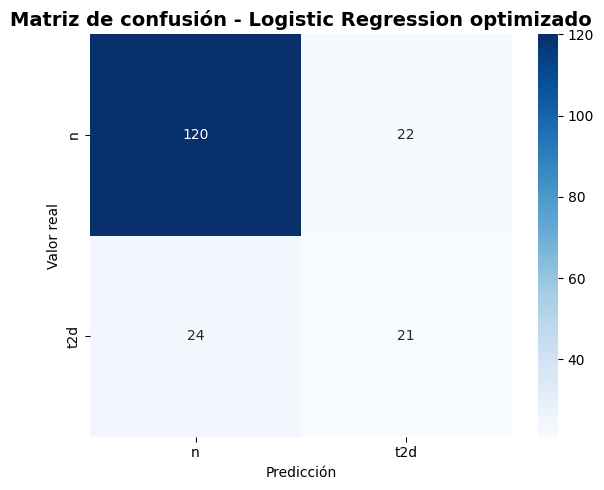

In [191]:
cm_logistic_optimized = confusion_matrix(y_test, y_pred_logistic_opt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic_optimized,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["n", "t2d"],
    yticklabels=["n", "t2d"]
)

plt.title("Matriz de confusión - Logistic Regression optimizado", fontsize=14, fontweight="bold")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.tight_layout()

# Guardar gráfico
plt.savefig(
     f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/confusion_matrix_logistic_optimized.png",
     dpi=300,
     bbox_inches="tight"
)

plt.show()

11.3.5.6. Comparar modelo base vs modelo optimizado

In [192]:
logistic_base_metrics = results_df[results_df["model"] == "Logistic Regression"].copy()

logistic_comparison = pd.concat([
    logistic_base_metrics,
    pd.DataFrame([metrics_logistic_optimized])
], ignore_index=True)

logistic_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.759358,0.500000,0.622222,0.554455,0.745070
1,Logistic Regression Optimized,0.754011,0.488372,0.466667,0.477273,0.766197


## 12. Selección del modelo final

## 13. Interpretabilidad del modelo final

## 14. Guardado del modelo final